# Matched filter

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io
from skimage.feature import match_template
from skimage.feature import peak_local_max

plt.rcParams['image.cmap'] = 'gray'

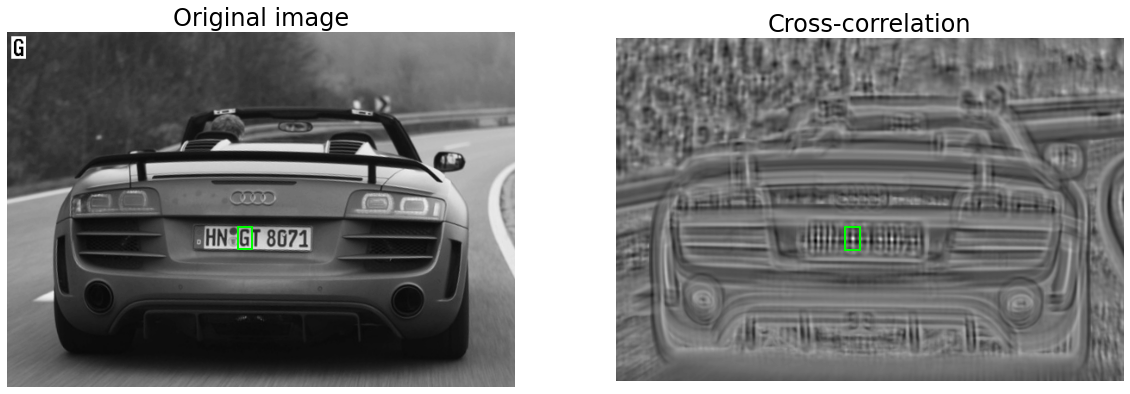

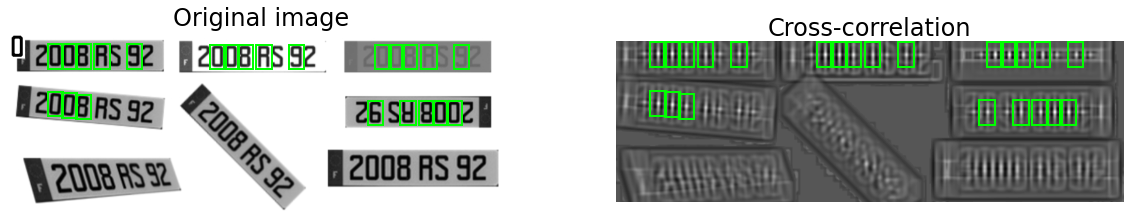

In [3]:
# Images
files = [
    ['audir8', 'pattern-G'],
    ['plates', 'pattern-0']
]

for fimg, fpattern in files:
    
    # Load image
    img = io.imread(f'{fimg}.png')
    
    # Load pattern
    pattern = io.imread(f'{fpattern}.png')
    h, w = pattern.shape
    
    # Matched filter
    result = match_template(img, pattern)
    candidats = peak_local_max(result, min_distance=10, threshold_abs=.7)
    
    # Modify image to include pattern
    offset = 5
    img[offset:(offset+h), offset:(offset+w)] = pattern
    
    # Display results
    fig, axs = plt.subplots(1, 2, figsize=(20,12))
    axs[0].imshow(img)
    axs[0].set_title('Original image', fontsize=24)
    axs[1].imshow(result)
    for c in candidats:
        y, x = c
        rect = plt.Rectangle((x, y), w, h, edgecolor='#00FF00', facecolor='none', linewidth=2)
        axs[0].add_patch(rect)
        rect = plt.Rectangle((x-w/2, y-h/2), w, h, edgecolor='#00FF00', facecolor='none', linewidth=2)
        axs[1].add_patch(rect)
    axs[1].set_title('Cross-correlation', fontsize=24)

    for i in range(2):
        axs[i].set_axis_off()
    plt.savefig(f'matched-filter-{fimg}.png', bbox_inches='tight')
    plt.show()